# Cell 1 — Setup

In [1]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import pyogrio
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# -------------------------------------------------------------------
# INPUTS
# -------------------------------------------------------------------
in_gpkg = r"E:\World Bank deliverbale 1\knn\buildings_points_knn_metrics.gpkg"

# Use this cell first to confirm the layer name.
print(pyogrio.list_layers(in_gpkg))

[['wb_buildings_extent_point_knn' 'Point']]


In [15]:
in_layer = "wb_buildings_extent_point_knn"

# Cell 2 — Read the NN point layer

In [16]:
in_layer = "wb_buildings_extent_point_knn"

gdf = pyogrio.read_dataframe(in_gpkg, layer=in_layer)

print("Rows:", f"{len(gdf):,}")
print("Columns:")
print(gdf.columns.tolist())
print("CRS:", gdf.crs)

gdf.head()

Rows: 578,379
Columns:
['type', 'building', 'construction', 'area_m_utm', 'ORIG_FID', 'building_id', 'd5_near', 'd80_near', 'r80_5', 'd5_q4', 'd5_q5', 'd80_q4', 'd80_q5', 'r80_5_q4', 'r80_5_q5', 'geometry']
CRS: EPSG:32636


,type,building,construction,area_m_utm,ORIG_FID,building_id,d5_near,d80_near,r80_5,d5_q4,d5_q5,d80_q4,d80_q5,r80_5_q4,r80_5_q5,geometry
0,multipolygon,yes,None,297.854874,1,1,24.751932,139.705179,5.644213,4,4,4,5,4,5,POINT (344402.388 536236.527)
1,multipolygon,yes,None,134.675182,2,2,13.947397,85.227719,6.110654,2,2,3,4,4,5,POINT (343156.5 537298.568)
2,multipolygon,yes,None,254.245943,3,3,16.169194,64.679283,4.000155,2,3,1,2,2,2,POINT (343313.65 538071.93)
3,multipolygon,yes,None,331.438943,4,4,34.483712,113.930039,3.303880,4,5,4,5,1,1,POINT (346336.899 536569.205)
4,multipolygon,yes,None,431.678814,5,5,37.518905,139.469801,3.717321,4,5,4,5,1,2,POINT (343792.458 541426.962)


# Cell 3 — Join in d20_near if needed

In [17]:
knn_folder = r"E:\World Bank deliverbale 1\knn"
summary_csv_folder = os.path.join(knn_folder, "summary_csvs")
wide_csv = os.path.join(summary_csv_folder, "knn_summary_all_k_wide.csv")

wide = pd.read_csv(wide_csv)

print("Wide CSV rows:", f"{len(wide):,}")
print(wide.columns.tolist())

Wide CSV rows: 578,379
['building_id', 'neighbor_count_k5', 'mean_dist_k5', 'median_dist_k5', 'min_dist_k5', 'dist_to_5th_neighbor', 'std_dist_k5', 'max_near_rank_k5', 'complete_k5', 'neighbor_count_k10', 'mean_dist_k10', 'median_dist_k10', 'min_dist_k10', 'dist_to_10th_neighbor', 'std_dist_k10', 'max_near_rank_k10', 'complete_k10', 'neighbor_count_k20', 'mean_dist_k20', 'median_dist_k20', 'min_dist_k20', 'dist_to_20th_neighbor', 'std_dist_k20', 'max_near_rank_k20', 'complete_k20', 'neighbor_count_k40', 'mean_dist_k40', 'median_dist_k40', 'min_dist_k40', 'dist_to_40th_neighbor', 'std_dist_k40', 'max_near_rank_k40', 'complete_k40', 'neighbor_count_k80', 'mean_dist_k80', 'median_dist_k80', 'min_dist_k80', 'dist_to_80th_neighbor', 'std_dist_k80', 'max_near_rank_k80', 'complete_k80']


# Now create a compact table with the KNN variables we need:

In [18]:
knn_vars = wide[
    [
        "building_id",
        "dist_to_5th_neighbor",
        "dist_to_20th_neighbor",
        "dist_to_80th_neighbor",
    ]
].copy()

knn_vars = knn_vars.rename(columns={
    "dist_to_5th_neighbor": "d5_near",
    "dist_to_20th_neighbor": "d20_near",
    "dist_to_80th_neighbor": "d80_near",
})

# Calculate ratios
knn_vars["r20_5"] = knn_vars["d20_near"] / knn_vars["d5_near"]
knn_vars["r80_20"] = knn_vars["d80_near"] / knn_vars["d20_near"]
knn_vars["r80_5"] = knn_vars["d80_near"] / knn_vars["d5_near"]

# Clean infinities
for col in ["r20_5", "r80_20", "r80_5"]:
    knn_vars[col] = knn_vars[col].replace([np.inf, -np.inf], np.nan)

print(knn_vars.head())
print(knn_vars.describe())

   building_id    d5_near   d20_near    d80_near     r20_5    r80_20     r80_5
0            1  24.751932  68.903548  139.705179  2.783764  2.027547  5.644213
1            2  13.947397  35.594186   85.227719  2.552031  2.394428  6.110654
2            3  16.169194  29.950318   64.679283  1.852307  2.159552  4.000155
3            4  34.483712  54.363906  113.930039  1.576510  2.095693  3.303880
4            5  37.518905  65.894814  139.469801  1.756310  2.116552  3.717321
         building_id        d5_near       d20_near       d80_near  \
count  578379.000000  578379.000000  578379.000000  578379.000000   
mean   289190.000000      21.005756      44.913175      92.707942   
std    166963.780009      14.568866      29.324642      58.166055   
min         1.000000       2.529629       7.188514      23.848991   
25%    144595.500000      13.634169      30.802196      64.878347   
50%    289190.000000      17.504219      37.684463      76.872505   
75%    433784.500000      23.767875      49

# Now join those variables to point layer. Based on earlier layer,  point ID is probably ORIG_FID.

In [19]:
if "ORIG_FID" not in gdf.columns:
    raise ValueError(f"ORIG_FID not found. Available columns: {gdf.columns.tolist()}")

gdf["ORIG_FID"] = pd.to_numeric(gdf["ORIG_FID"], errors="coerce").astype("Int64")
knn_vars["building_id"] = pd.to_numeric(knn_vars["building_id"], errors="coerce").astype("Int64")

# Drop duplicate versions of fields if already present
drop_cols = [
    "d5_near", "d20_near", "d80_near",
    "r20_5", "r80_20", "r80_5"
]
existing_drop_cols = [c for c in drop_cols if c in gdf.columns]
gdf_base = gdf.drop(columns=existing_drop_cols)

gdf2 = gdf_base.merge(
    knn_vars,
    left_on="ORIG_FID",
    right_on="building_id",
    how="left",
    validate="one_to_one"
)

print("Original rows:", f"{len(gdf):,}")
print("Joined rows:", f"{len(gdf2):,}")

matched = gdf2["d5_near"].notna().sum()
print("Matched:", f"{matched:,}")
print("Unmatched:", f"{len(gdf2) - matched:,}")
print("Match rate:", f"{matched / len(gdf2):.2%}")

Original rows: 578,379
Joined rows: 578,379
Matched: 578,379
Unmatched: 0
Match rate: 100.00%


# Cell 4 — Create log-transformed k-means variables

In [20]:
km_gdf = gdf2.copy()

# Required input fields
raw_feature_cols = [
    "d5_near",
    "d20_near",
    "d80_near",
    "r20_5",
    "r80_20",
]

# Check fields
missing = [c for c in raw_feature_cols if c not in km_gdf.columns]
if missing:
    raise ValueError(f"Missing required fields: {missing}")

# Values must be positive for log transform
for col in raw_feature_cols:
    km_gdf[col] = pd.to_numeric(km_gdf[col], errors="coerce")

# Create log variables
km_gdf["log_d5"] = np.log(km_gdf["d5_near"])
km_gdf["log_d20"] = np.log(km_gdf["d20_near"])
km_gdf["log_d80"] = np.log(km_gdf["d80_near"])
km_gdf["log_r20_5"] = np.log(km_gdf["r20_5"])
km_gdf["log_r80_20"] = np.log(km_gdf["r80_20"])

feature_cols = [
    "log_d5",
    "log_d20",
    "log_d80",
    "log_r20_5",
    "log_r80_20",
]

# Keep only valid rows for clustering
valid_mask = km_gdf[feature_cols].replace([np.inf, -np.inf], np.nan).notna().all(axis=1)

print("Total rows:", f"{len(km_gdf):,}")
print("Valid rows for k-means:", f"{valid_mask.sum():,}")
print("Invalid rows:", f"{len(km_gdf) - valid_mask.sum():,}")

X = km_gdf.loc[valid_mask, feature_cols].copy()

X.describe()

Total rows: 578,379
Valid rows for k-means: 578,379
Invalid rows: 0


,log_d5,log_d20,log_d80,log_r20_5,log_r80_20
count,578379.000000,578379.000000,578379.000000,578379.000000,578379.000000
mean,2.919556,3.696497,4.427088,0.776941,0.730591
std,0.461927,0.423786,0.408473,0.232699,0.150441
min,0.928073,1.972484,3.171742,0.034600,0.057959
25%,2.612579,3.427586,4.172514,0.613327,0.633916
50%,2.862442,3.629248,4.342148,0.751621,0.717467
75%,3.168335,3.909254,4.614754,0.912336,0.810898
max,6.517542,6.738560,7.212494,3.464865,3.308976


# Cell 5 — Standardize the variables

In [21]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols, index=X.index)

X_scaled_df.describe()

,log_d5,log_d20,log_d80,log_r20_5,log_r80_20
count,5.783790e+05,5.783790e+05,5.783790e+05,5.783790e+05,5.783790e+05
mean,5.255554e-16,1.231456e-16,2.088462e-16,-3.376920e-16,-5.247200e-16
std,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00
min,-4.311252e+00,-4.068124e+00,-3.073268e+00,-3.190137e+00,-4.471068e+00
25%,-6.645581e-01,-6.345452e-01,-6.232332e-01,-7.031126e-01,-6.426069e-01
50%,-1.236440e-01,-1.586869e-01,-2.079438e-01,-1.088073e-01,-8.723381e-02
75%,5.385666e-01,5.020382e-01,4.594350e-01,5.818469e-01,5.338133e-01
max,7.789077e+00,7.178306e+00,6.819077e+00,1.155110e+01,1.713887e+01


# Cell 6 — Compare candidate values of k

In [22]:
k_candidates = range(2, 7)

inertias = []
silhouettes = []

# Silhouette sample
silhouette_sample_size = 50_000

if len(X_scaled_df) > silhouette_sample_size:
    X_sil = X_scaled_df.sample(silhouette_sample_size, random_state=42)
else:
    X_sil = X_scaled_df

for k in k_candidates:
    print(f"Testing k={k}...")

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20,
        max_iter=300
    )

    labels = model.fit_predict(X_scaled_df)

    inertias.append(model.inertia_)

    # Fit a separate model on the sample for silhouette to reduce computation time
    model_sil = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20,
        max_iter=300
    )
    sil_labels = model_sil.fit_predict(X_sil)

    sil = silhouette_score(X_sil, sil_labels)
    silhouettes.append(sil)

    print(f"  inertia: {model.inertia_:,.2f}")
    print(f"  silhouette sample score: {sil:.4f}")

results = pd.DataFrame({
    "k": list(k_candidates),
    "inertia": inertias,
    "silhouette_sample": silhouettes
})

results

Testing k=2...
  inertia: 1,912,235.01
  silhouette sample score: 0.3645
Testing k=3...
  inertia: 1,585,596.59
  silhouette sample score: 0.2315
Testing k=4...
  inertia: 1,347,680.15
  silhouette sample score: 0.2435
Testing k=5...
  inertia: 1,209,554.47
  silhouette sample score: 0.2397
Testing k=6...
  inertia: 1,088,694.39
  silhouette sample score: 0.2441


,k,inertia,silhouette_sample
0,2,1.912235e+06,0.364515
1,3,1.585597e+06,0.231483
2,4,1.347680e+06,0.243452
3,5,1.209554e+06,0.239726
4,6,1.088694e+06,0.244137


# Cell 7 — Plot elbow and silhouette scores

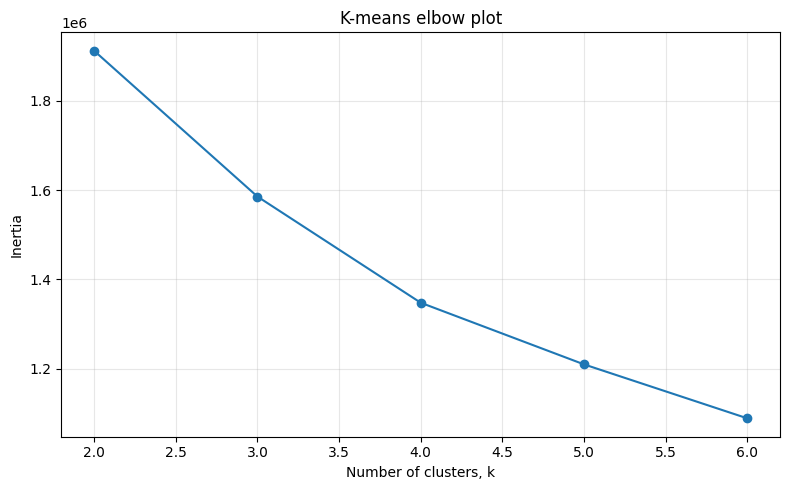

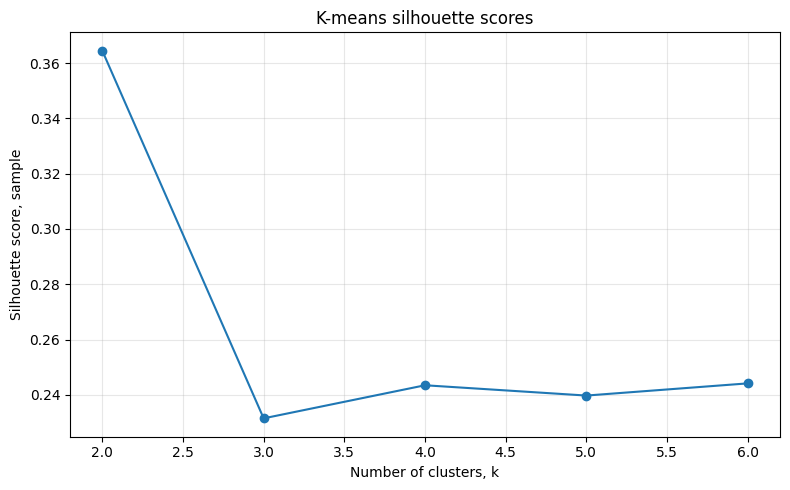

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(results["k"], results["inertia"], marker="o")
plt.xlabel("Number of clusters, k")
plt.ylabel("Inertia")
plt.title("K-means elbow plot")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(results["k"], results["silhouette_sample"], marker="o")
plt.xlabel("Number of clusters, k")
plt.ylabel("Silhouette score, sample")
plt.title("K-means silhouette scores")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Cell 8 — Run k-means for selected values and attach cluster labels

In [24]:
selected_k_values = [2, 3, 4, 5, 6]

for k in selected_k_values:
    print(f"Running final k-means for k={k}")

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=50,
        max_iter=500
    )

    labels = model.fit_predict(X_scaled_df)

    # Store cluster labels in original GeoDataFrame
    # Use 1-based cluster labels for easier mapping
    km_gdf[f"km{k}"] = pd.Series(index=km_gdf.index, dtype="Int64")
    km_gdf.loc[valid_mask, f"km{k}"] = labels + 1

print(km_gdf[[f"km{k}" for k in selected_k_values]].head())

Running final k-means for k=2
Running final k-means for k=3
Running final k-means for k=4
Running final k-means for k=5
Running final k-means for k=6
   km2  km3  km4  km5  km6
0    1    2    2    2    4
1    2    3    4    1    5
2    2    1    3    4    1
3    1    1    1    2    6
4    1    2    2    2    6


# Cell 9 — Summarize cluster profiles

In [25]:
profile_vars = [
    "d5_near",
    "d20_near",
    "d80_near",
    "r20_5",
    "r80_20",
    "r80_5",
]

cluster_profiles = {}

for k in selected_k_values:
    label_col = f"km{k}"

    profile = (
        km_gdf.loc[valid_mask]
        .groupby(label_col)[profile_vars]
        .agg(["count", "median", "mean", "std"])
    )

    cluster_profiles[k] = profile

    print("\n" + "=" * 80)
    print(f"Cluster profile for k={k}")
    display(profile)


Cluster profile for k=2


d5_near                                  d20_near                        \
      count     median       mean        std    count     median       mean   
km2                                                                           
1    165971  29.685627  34.748653  20.811680   165971  61.352469  72.660379   
2    412408  15.216961  15.475014   4.094571   412408  33.617102  33.746487   

               d80_near              ...     r20_5            r80_20  \
           std    count      median  ...      mean       std   count   
km2                                  ...                               
1    42.161323   165971  124.624466  ...  2.195432  0.808164  165971   
2     7.489880   412408   69.645736  ...  2.257333  0.525608  412408   

                                    r80_5                                
       median      mean       std   count    median      mean       std  
km2                                                                      
1    1.971338  2.043510  0.487664  165971  4.058639  4.526190  2.294089  
2    2.076955  2.125155  0.312646  412408  4.568365  4.794028  1.321556  

[2 rows x 24 columns]


Cluster profile for k=3


d5_near                                  d20_near                        \
      count     median       mean        std    count     median       mean   
km3                                                                           
1    237650  20.046939  21.139554   4.696881   237650  39.930287  40.884292   
2    103983  34.191265  39.555748  24.814046   103983  71.686282  85.585771   
3    236746  12.940010  12.723965   2.492319   236746  30.427150  31.093323   

               d80_near              ...     r20_5            r80_20  \
           std    count      median  ...      mean       std   count   
km3                                  ...                               
1     7.970557   237650   78.065751  ...  1.966869  0.334855  237650   
2    48.740171   103983  146.407239  ...  2.328079  0.937108  103983   
3     7.734110   236746   66.653802  ...  2.474438  0.556349  236746   

                                    r80_5                                
       median      mean       std   count    median      mean       std  
km3                                                                      
1    1.951181  1.971147  0.215537  237650  3.818910  3.861930  0.682207  
2    2.017621  2.106811  0.576142  103983  4.388735  4.941364  2.697579  
3    2.178425  2.230571  0.337895  236746  5.226194  5.477205  1.330598  

[3 rows x 24 columns]


Cluster profile for k=4


d5_near                                  d20_near                        \
      count     median       mean        std    count     median       mean   
km4                                                                           
1    193359  21.284977  22.363423   4.917884   193359  40.227045  41.644215   
2     87378  36.567707  42.648807  25.805572    87378  74.955515  89.835417   
3    171594  13.180744  13.015479   2.829777   171594  27.881168  27.461992   
4    126048  14.589021  14.797330   3.361824   126048  39.944399  42.544120   

               d80_near              ...     r20_5            r80_20  \
           std    count      median  ...      mean       std   count   
km4                                  ...                               
1     7.932886   193359   78.941508  ...  1.885900  0.241782  193359   
2    51.759231    87378  152.985797  ...  2.213607  0.816703   87378   
3     4.972518   171594   62.557154  ...  2.150084  0.324152  171594   
4    11.093014   126048   79.765978  ...  2.921924  0.635244  126048   

                                    r80_5                                
       median      mean       std   count    median      mean       std  
km4                                                                      
1    1.946417  1.963624  0.208075  193359  3.690121  3.699497  0.585916  
2    2.016369  2.112903  0.608610   87378  4.235798  4.721264  2.523492  
3    2.252140  2.310360  0.339177  171594  4.775853  4.977141  1.142689  
4    1.987130  2.021807  0.253835  126048  5.562454  5.921542  1.691631  

[4 rows x 24 columns]


Cluster profile for k=5


d5_near                                  d20_near                          \
      count     median       mean        std    count      median        mean   
km5                                                                             
1    135862  12.320017  12.310958   2.730451   135862   27.095428   26.844911   
2    111365  29.679403  31.578681   8.200207   111365   58.422057   60.646624   
3    117568  14.473470  14.727607   3.282646   117568   40.370051   42.652292   
4    182393  18.802481  19.148571   3.420695   182393   35.841461   36.098885   
5     31191  46.750087  55.653115  38.166186    31191  106.200938  127.504536   

               d80_near              ...     r20_5            r80_20  \
           std    count      median  ...      mean       std   count   
km5                                  ...                               
1     5.224137   135862   62.810599  ...  2.218759  0.345322  135862   
2    11.738406   111365  117.600102  ...  1.971880  0.342351  111365   
3    10.410318   117568   80.249159  ...  2.940730  0.578054  117568   
4     5.423188   182393   70.878262  ...  1.907511  0.234688  182393   
5    71.791105    31191  222.098670  ...  2.584866  1.322288   31191   

                                    r80_5                                
       median      mean       std   count    median      mean       std  
km5                                                                      
1    2.319442  2.380046  0.353151  135862  5.059730  5.283692  1.212958  
2    1.979781  2.013837  0.290141  111365  3.889656  3.979292  0.926181  
3    1.984471  2.012611  0.239136  117568  5.584978  5.927897  1.451936  
4    1.973725  1.983598  0.188213  182393  3.786836  3.776891  0.534366  
5    2.042839  2.229889  0.907600   31191  4.880502  5.818842  4.126885  

[5 rows x 24 columns]


Cluster profile for k=6


d5_near                                  d20_near                          \
      count     median       mean        std    count      median        mean   
km6                                                                             
1    176694  18.669340  19.000021   3.156844   176694   35.462957   35.659963   
2     25647  53.315438  62.857206  39.109012    25647  112.827465  137.482088   
3    113580  14.215825  14.419177   3.093288   113580   39.084083   41.072253   
4     42869  22.136749  23.303749   7.011604    42869   54.379778   57.518039   
5    123104  12.030088  11.900091   2.415534   123104   26.502844   26.046369   
6     96485  30.206386  31.904571   7.486787    96485   57.992109   60.245562   

               d80_near              ...     r20_5            r80_20  \
           std    count      median  ...      mean       std   count   
km6                                  ...                               
1     5.107040   176694   70.817520  ...  1.895914  0.223146  176694   
2    74.834146    25647  217.630950  ...  2.411595  1.217019   25647   
3     9.490459   113580   76.888531  ...  2.894441  0.561251  113580   
4    18.182805    42869  133.215793  ...  2.555729  0.854274   42869   
5     4.667465   123104   61.426903  ...  2.224453  0.343497  123104   
6    11.229326    96485  111.653234  ...  1.931101  0.331239   96485   

                                    r80_5                                
       median      mean       std   count    median      mean       std  
km6                                                                      
1    1.998575  2.009404  0.190556  176694  3.807327  3.804263  0.533557  
2    1.900994  1.953689  0.397975   25647  4.182443  4.694810  2.397614  
3    1.954560  1.964519  0.186972  113580  5.412643  5.690515  1.253151  
4    2.479105  2.635860  0.736348   42869  5.934924  6.738880  3.311724  
5    2.307792  2.351994  0.305964  123104  5.048514  5.232383  1.085885  
6    1.913451  1.915031  0.199621   96485  3.678184  3.693512  0.697633  

[6 rows x 24 columns]

# A simpler median-only table is easier to read:

In [29]:
for k in selected_k_values:
    label_col = f"km{k}"

    median_profile = (
        km_gdf.loc[valid_mask]
        .groupby(label_col)[profile_vars]
        .median()
        .round(2)
    )

    counts = km_gdf.loc[valid_mask][label_col].value_counts().sort_index()
    shares = counts / counts.sum()

    median_profile.insert(0, "count", counts)
    median_profile.insert(1, "share", shares.round(3))

    print("\n" + "=" * 80)
    print(f"Median cluster profile for k={k}")
    display(median_profile)


Median cluster profile for k=2


,count,share,d5_near,d20_near,d80_near,r20_5,r80_20,r80_5
km2,,,,,,,,
1,165971,0.287,29.69,61.35,124.62,2.02,1.97,4.06
2,412408,0.713,15.22,33.62,69.65,2.16,2.08,4.57



Median cluster profile for k=3


,count,share,d5_near,d20_near,d80_near,r20_5,r80_20,r80_5
km3,,,,,,,,
1,237650,0.411,20.05,39.93,78.07,1.92,1.95,3.82
2,103983,0.18,34.19,71.69,146.41,2.12,2.02,4.39
3,236746,0.409,12.94,30.43,66.65,2.37,2.18,5.23



Median cluster profile for k=4


,count,share,d5_near,d20_near,d80_near,r20_5,r80_20,r80_5
km4,,,,,,,,
1,193359,0.334,21.28,40.23,78.94,1.88,1.95,3.69
2,87378,0.151,36.57,74.96,152.99,2.06,2.02,4.24
3,171594,0.297,13.18,27.88,62.56,2.12,2.25,4.78
4,126048,0.218,14.59,39.94,79.77,2.77,1.99,5.56



Median cluster profile for k=5


,count,share,d5_near,d20_near,d80_near,r20_5,r80_20,r80_5
km5,,,,,,,,
1,135862,0.235,12.32,27.10,62.81,2.19,2.32,5.06
2,111365,0.193,29.68,58.42,117.60,1.94,1.98,3.89
3,117568,0.203,14.47,40.37,80.25,2.79,1.98,5.58
4,182393,0.315,18.80,35.84,70.88,1.90,1.97,3.79
5,31191,0.054,46.75,106.20,222.10,2.29,2.04,4.88



Median cluster profile for k=6


,count,share,d5_near,d20_near,d80_near,r20_5,r80_20,r80_5
km6,,,,,,,,
1,176694,0.305,18.67,35.46,70.82,1.90,2.00,3.81
2,25647,0.044,53.32,112.83,217.63,2.12,1.90,4.18
3,113580,0.196,14.22,39.08,76.89,2.75,1.95,5.41
4,42869,0.074,22.14,54.38,133.22,2.40,2.48,5.93
5,123104,0.213,12.03,26.50,61.43,2.19,2.31,5.05
6,96485,0.167,30.21,57.99,111.65,1.89,1.91,3.68


# Cell 10 — PCA plot of clusters

Explained variance ratio: [0.55215023 0.24773746]


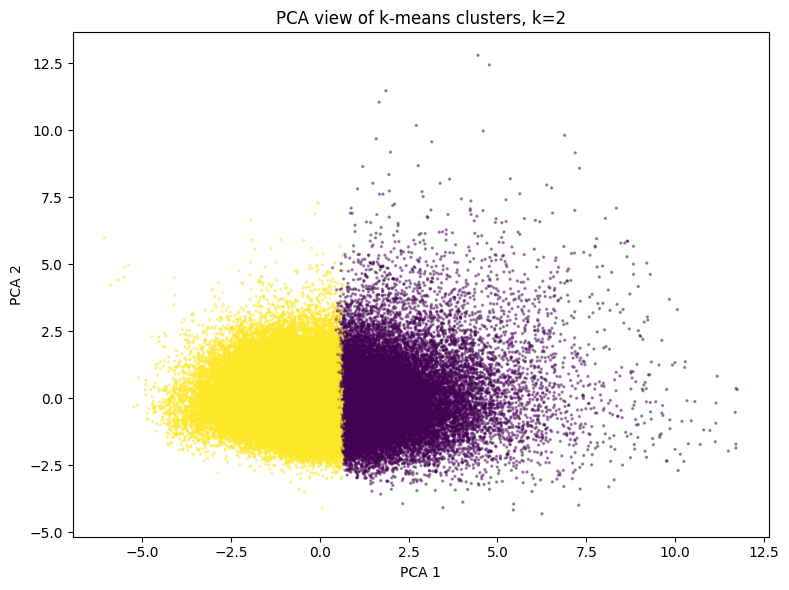

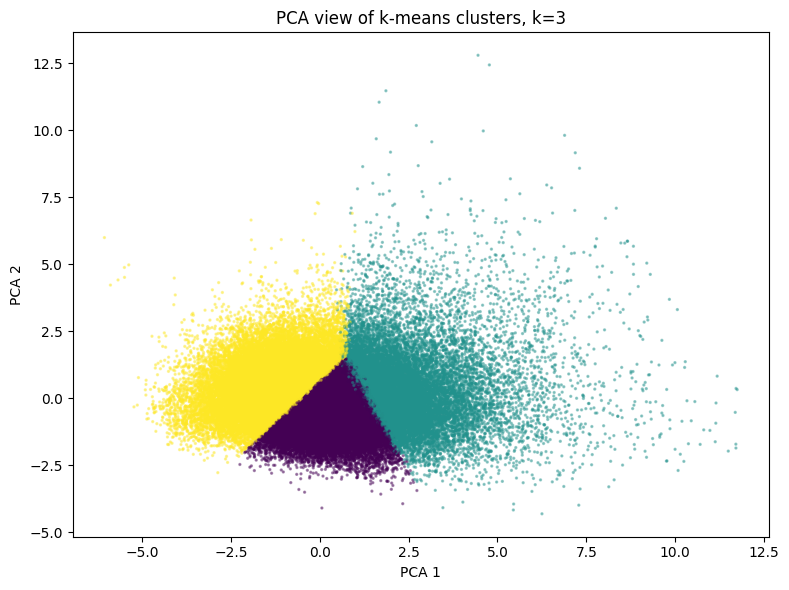

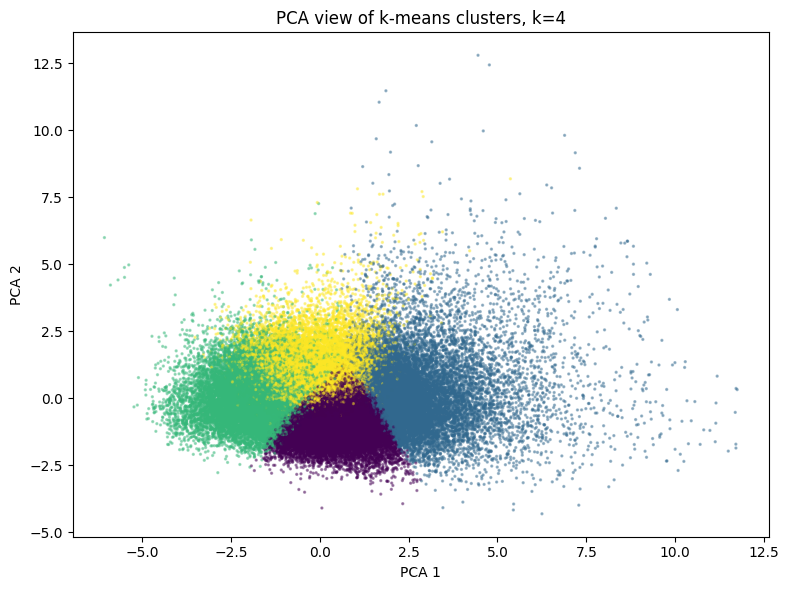

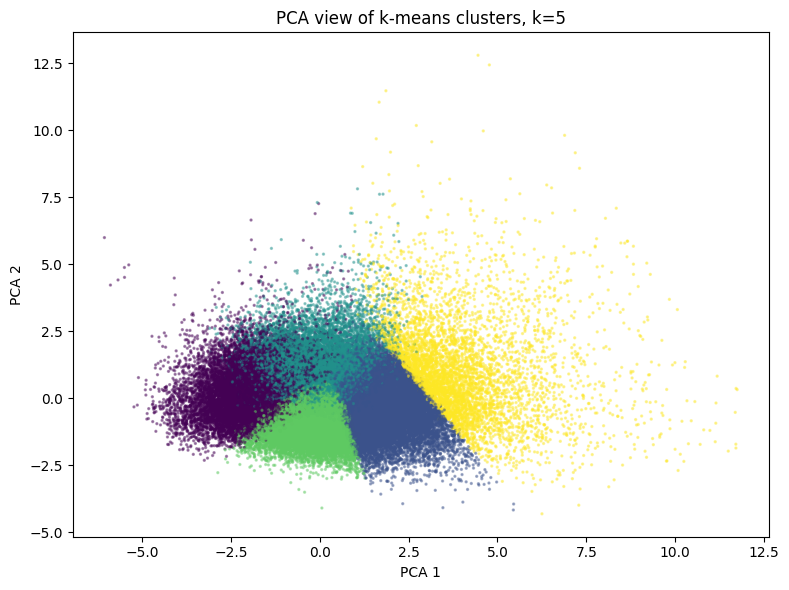

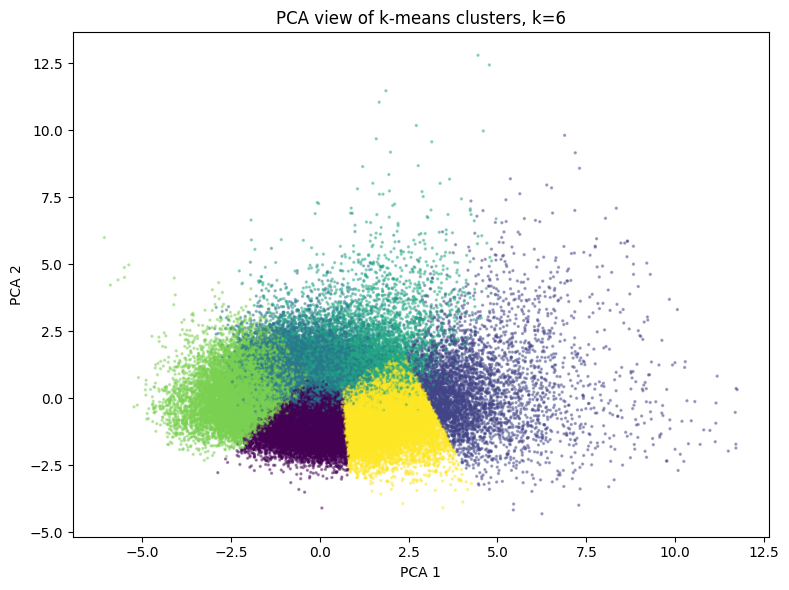

In [26]:
# Use a sample for plotting
plot_sample_size = 100_000

if len(X_scaled_df) > plot_sample_size:
    sample_idx = X_scaled_df.sample(plot_sample_size, random_state=42).index
else:
    sample_idx = X_scaled_df.index

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled_df.loc[sample_idx])

print("Explained variance ratio:", pca.explained_variance_ratio_)

for k in selected_k_values:
    label_col = f"km{k}"
    labels_sample = km_gdf.loc[sample_idx, label_col]

    plt.figure(figsize=(8, 6))
    plt.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=labels_sample,
        s=2,
        alpha=0.4
    )
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.title(f"PCA view of k-means clusters, k={k}")
    plt.tight_layout()
    plt.show()

# Export the current km_gdf to a new GeoPackage

In [28]:
import os

knn_folder = r"E:\World Bank deliverbale 1\knn"

out_gpkg = os.path.join(knn_folder, "buildings_points_knn_kmeans.gpkg")
out_layer = "wb_buildings_extent_point_knn_kmeans"

# Remove old output if it already exists
if os.path.exists(out_gpkg):
    os.remove(out_gpkg)

# Fields to keep
keep_cols = [
    "type",
    "building",
    "construction",
    "area_m_utm",
    "ORIG_FID",
    "building_id",
    "d5_near",
    "d20_near",
    "d80_near",
    "r20_5",
    "r80_20",
    "r80_5",
    "log_d5",
    "log_d20",
    "log_d80",
    "log_r20_5",
    "log_r80_20",
    "km2",
    "km3",
    "km4",
    "km5",
    "km6",
    "geometry",
]

# Keep only fields that actually exist
keep_cols = [c for c in keep_cols if c in km_gdf.columns]

export_gdf = km_gdf[keep_cols].copy()

# Export
export_gdf.to_file(out_gpkg, layer=out_layer, driver="GPKG")

print("Exported:")
print(out_gpkg)
print("Layer:", out_layer)
print("Rows:", f"{len(export_gdf):,}")
print("Columns:")
print(export_gdf.columns.tolist())

Exported:
E:\World Bank deliverbale 1\knn\buildings_points_knn_kmeans.gpkg
Layer: wb_buildings_extent_point_knn_kmeans
Rows: 578,379
Columns:
['type', 'building', 'construction', 'area_m_utm', 'ORIG_FID', 'd5_near', 'd20_near', 'd80_near', 'r20_5', 'r80_20', 'r80_5', 'log_d5', 'log_d20', 'log_d80', 'log_r20_5', 'log_r80_20', 'km2', 'km3', 'km4', 'km5', 'km6', 'geometry']
